In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def calculate_edge_flows(G, sinks, sources, demands_timeseries, noise_level=0.0):
    """
    Calculates the flow passing through edges in a NetworkX DiGraph based on
    demand nodes routing traffic to the nearest sink node.

    Args:
        G (nx.DiGraph): The network topology.
        sinks (list): List of node IDs acting as sinks (destinations).
        sources (list): List of node IDs acting as demand nodes.
        demands_timeseries (list of np.array or list): A list containing the
                                                       time series data for each source.
                                                       Order must match the 'sources' list.
        noise_level (float): A value between 0 and 1 representing the magnitude of noise.
                             0.0 means perfect conservation.
                             0.1 means flow can fluctuate by +/- 10% per edge.

    Returns:
        dict: A dictionary where keys are edge tuples (u, v) and values are
              numpy arrays representing the flow over time.
    """

    # 1. Input Validation
    if len(sources) != len(demands_timeseries):
        raise ValueError("The number of sources must match the number of time series provided.")

    if not sinks:
        raise ValueError("No sink nodes provided. Traffic has nowhere to go.")

    # Check time series alignment (assuming all series are same length)
    time_steps = len(demands_timeseries[0])

    # 2. Initialize Edge Flows with Zeros
    # We use a dictionary to store a numpy array for each edge
    edge_flows = {edge: np.zeros(time_steps) for edge in G.edges()}

    # 3. Process each Source
    for i, source in enumerate(sources):
        demand_profile = np.array(demands_timeseries[i], dtype=float)

        # A. Find the nearest sink for this specific source
        # We calculate shortest path length to all sinks and pick the minimum
        best_sink = None
        shortest_path_len = float('inf')
        selected_path = []

        # Optimization: In dense graphs, run Dijkstra once from source to all nodes
        try:
            paths = nx.single_source_shortest_path(G, source)
        except nx.NetworkXNoPath:
            print(f"Warning: Node {source} is disconnected from the network.")
            continue

        for sink in sinks:
            if sink in paths:
                path_to_sink = paths[sink]
                dist = len(path_to_sink) - 1 # Hops

                if dist < shortest_path_len:
                    shortest_path_len = dist
                    best_sink = sink
                    selected_path = path_to_sink

        if best_sink is None:
            print(f"Warning: No path found from source {source} to any sink.")
            continue

        # B. Route the Flow (Superposition)
        # Iterate through the edges in the path and add the demand timeseries
        for u, v in zip(selected_path[:-1], selected_path[1:]):
            if (u, v) in edge_flows:
                current_demand = demand_profile.copy()

                # Apply Noise if requested
                # We apply independent noise for every edge traversal to simulate
                # link-specific variability, breaking perfect path conservation.
                if noise_level > 0.0:
                    # Generate random factors between [1-noise, 1+noise]
                    # e.g., noise=0.1 => factors in [0.9, 1.1]
                    noise_factors = np.random.uniform(
                        1.0 - noise_level,
                        1.0 + noise_level,
                        size=time_steps
                    )
                    # Ensure flow doesn't drop below zero
                    noise_factors = np.maximum(noise_factors, 0.0)
                    current_demand = current_demand * noise_factors

                edge_flows[(u, v)] += current_demand
            else:
                raise KeyError(f"Edge ({u}, {v}) calculated in path but not found in graph edges.")

    return edge_flows


In [26]:
# Set seed for reproducibility in example
np.random.seed(42)

def generate_noisy_sinusoid():
    # Random amplitude between 5 and 10
    amplitude = np.random.uniform(5, 10)
    # Random phase shift
    phase = np.random.uniform(0, 2 * np.pi)
    # Random offset to ensure values stay positive (min 15 so 15-10 > 0)
    offset = 20

    # Base signal: A * sin(t + phi) + offset
    signal = amplitude * np.sin(t + phase) + offset

    # Add random noise to the signal itself (simulating demand fluctuation)
    signal_noise = np.random.normal(0, 4.0, num_steps)

    return np.maximum(signal + signal_noise, 0)

G = nx.DiGraph()

bidirectional_edges = [
    ('MR_A', 'MR_B'),
    ('MR_B', 'MR_A'),
    ('MR_A', 'HR_A'),
    ('HR_A', 'MR_A'),
    ('MR_A', 'D'),
    ('D', 'MR_A'),
    ('MR_B', 'HR_B'),
    ('HR_B', 'MR_B'),
    ('MR_B', 'B'),
    ('B', 'MR_B'),
    ('D', 'E'),
    ('E', 'D'),
    ('D', 'F'),
    ('F', 'D'),
    ('B', 'C'),
    ('C', 'B'),
    ('B', 'E'),
    ('E', 'B'),
]
G.add_edges_from(bidirectional_edges)

# Unidirectional
unidirectional_edges = [
    ('INPUT','HR_A'),
    ('INPUT','HR_B'),
    
    ('MR_B', 'A'),
    ('A', 'S1_A'),
    ('D', 'S1_D'),
    ('E', 'S1_E'),
    ('F', 'S1_F'),
    ('C', 'S1_C'),

    ('S1_A','OUTPUT'),
    ('S1_C','OUTPUT'),
    ('S1_D','OUTPUT'),
    ('S1_E','OUTPUT'),
    ('S1_F','OUTPUT'),
]
G.add_edges_from(unidirectional_edges)

# 2. Define Network Roles
sinks = ['HR_A', 'HR_B']
demand_nodes = ['S1_A', 'S1_C', 'S1_F','S1_E','S1_D']

# 3. Create Noisy Sinusoid Time Series
# Parameters: 100 steps, Amplitude [5, 10]
num_steps = 1000
t = np.linspace(0, 4 * np.pi, num_steps) # 2 full cycles (4*pi)

all_series = [generate_noisy_sinusoid() for x in demand_nodes]



In [27]:
CAPACITY = pd.DataFrame(G.edges(), columns=['A', 'B'])
CAPACITY['Capacity'] = 1000
CAPACITY

,A,B,Capacity
0,MR_A,MR_B,1000
1,MR_A,HR_A,1000
2,MR_A,D,1000
3,MR_B,MR_A,1000
4,MR_B,HR_B,1000
5,MR_B,B,1000
6,MR_B,A,1000
7,HR_A,MR_A,1000
8,D,MR_A,1000
9,D,E,1000


In [28]:
# 4. Calculate Flows WITH NETWORK NOISE
# We inject 10% noise variance per edge traversal (network noise)
noise_param = 0.05
print(f"Calculating network flows with network noise_level={noise_param}...")
results = calculate_edge_flows(G.reverse(), sinks, demand_nodes, all_series, noise_level=noise_param)

# 5. Display Results
TSS = pd.DataFrame(results, index=[f"t{i}" for i in range(num_steps)])
TSS = TSS.loc[:,TSS.sum() > 0]
TSS.index = pd.date_range(start='2025-01-01', periods=1000, freq='24h')
ORIG_COLUMNS = TSS.columns
TSS.columns = [f"chn_{i}" for i in range(len(ORIG_COLUMNS))]
TSS

Calculating network flows with network noise_level=0.05...


,chn_0,chn_1,chn_2,chn_3,chn_4,chn_5,chn_6,chn_7,chn_8,chn_9,chn_10,chn_11,chn_12
2025-01-01,56.933698,39.621734,55.223023,17.976711,17.927667,17.572641,18.964477,20.522107,20.327663,20.821336,17.818682,16.866560,17.421120
2025-01-02,59.870223,40.631595,60.384894,16.157974,10.071950,24.100144,15.358708,23.520994,23.052178,26.001480,9.881963,25.088347,16.230353
2025-01-03,66.868180,37.848939,66.077436,21.833465,20.696891,23.609420,20.875762,17.057097,16.746480,23.876770,20.068336,24.562577,21.428188
2025-01-04,50.460371,36.727747,52.638751,19.041156,14.305841,21.092398,20.586031,17.167177,18.043926,18.179443,14.192748,20.612165,20.460630
2025-01-05,62.016936,45.334812,60.627455,21.106052,16.073740,26.368958,21.855613,25.061692,24.790652,19.553430,15.578099,27.034239,22.139591
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027-09-23,60.954877,34.083575,62.246733,13.726228,16.061917,22.452201,14.086616,20.716583,20.210093,23.046719,16.158041,23.345504,14.734215
2027-09-24,59.753391,33.371670,57.885616,17.431703,16.785029,16.841801,16.983567,15.869830,16.058123,26.051096,16.407059,16.212533,16.516880
2027-09-25,57.256364,34.325835,57.229129,14.626534,18.242342,20.537671,14.397700,20.141061,19.824132,18.071850,17.925237,20.100134,14.986953
2027-09-26,62.107699,39.160800,62.256568,14.985554,10.883704,22.097535,15.049301,22.670886,23.874870,27.361783,10.893017,21.804707,14.682316



Generating graph visualization...


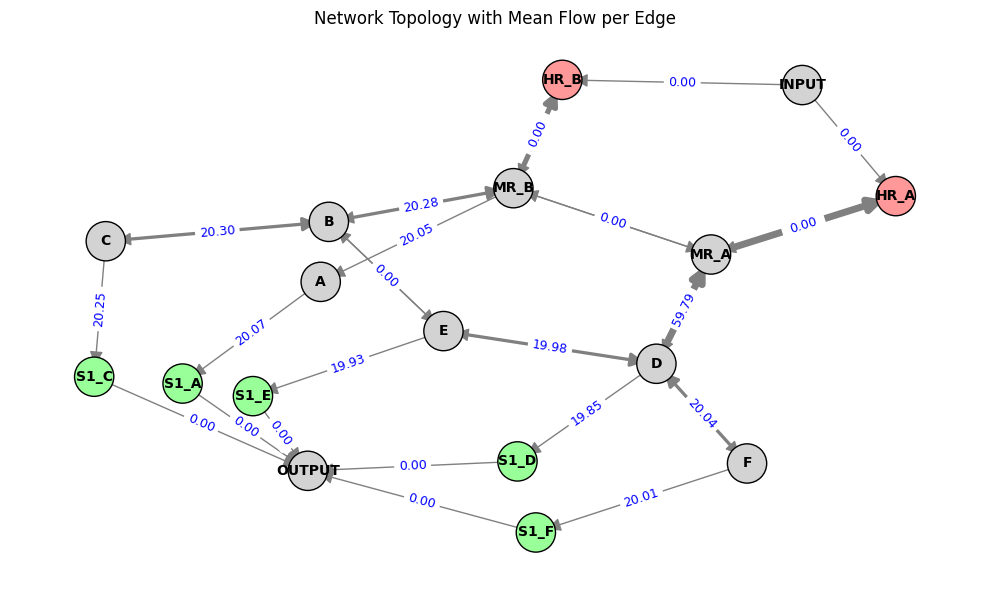

In [29]:
def draw_network_with_flows(G, edge_flows, sinks, sources):
    """
    Draws the network graph with edge labels showing the mean flow.
    """
    # Use a fixed layout for reproducibility
    #pos = nx.spring_layout(G, seed=52)

    # Use Kamada-Kawai layout to approximate fixed/equal edge lengths
    # This layout attempts to position nodes so that geometric distance matches graph distance
    try:
        pos = nx.kamada_kawai_layout(G)
    except ImportError:
        # Fallback if scipy is not available (required for kamada_kawai)
        print("Warning: Scipy not found. Using spring_layout as fallback.")
        pos = nx.spring_layout(G, seed=42, k=0.5, iterations=100)

    # Calculate mean flows for labels
    edge_means = {}
    for edge, flow_series in edge_flows.items():
        edge_means[edge] = np.mean(flow_series)

    # Define Node Colors
    node_colors = []
    for node in G.nodes():
        if node in sinks:
            node_colors.append('#ff9999') # Red for Sinks
        elif node in sources:
            node_colors.append('#99ff99') # Green for Sources
        else:
            node_colors.append('#d3d3d3') # Gray for others

    plt.figure(figsize=(10, 6))

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Draw Edges (Width proportional to mean flow)
    max_flow = max(edge_means.values()) if edge_means else 1.0
    # Base width 1, max width 5
    widths = [1 + 4 * (edge_means.get(e, 0) / max_flow) for e in G.edges()]

    nx.draw_networkx_edges(G, pos, width=widths, arrowstyle='-|>', arrowsize=20, edge_color='gray')

    # Draw Edge Labels (Mean Values)
    edge_labels = {e: f"{mean_val:.2f}" for e, mean_val in edge_means.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue', font_size=9)

    plt.title("Network Topology with Mean Flow per Edge")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 6. Visualize the Graph
print("\nGenerating graph visualization...")
draw_network_with_flows(G, results, sinks, demand_nodes)

# PATCHTST

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [7]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# PREDICTION FOR A DAY
SEQ_LEN = 90         # 3 months
PRED_LEN = 30          # 1 month

CHANNELS =  TSS.shape[1]
PATCH_LEN = 16
STRIDE = int(PATCH_LEN/2)
PATCH_NUM  = (SEQ_LEN - PRED_LEN) // STRIDE + 1 + 1

TIME_FEATURES = 4   #WEEK, DAY of WEEK, HOUR, MINUTE
D_MODEL = 128

print(f"PATCH_NUM: {PATCH_NUM}")
print(f"CHANNELS: {CHANNELS}")
print(f"PATCH_LEN: {PATCH_LEN}")
print(f"STRIDE: {STRIDE}")
print(f"TIME_FEATURES: {TIME_FEATURES}")
print(f"D_MODEL: {D_MODEL}")


PATCH_NUM: 9
CHANNELS: 13
PATCH_LEN: 16
STRIDE: 8
TIME_FEATURES: 4
D_MODEL: 128


In [8]:
class TimeSeriesDataset(Dataset):
    """
    Converts a Pandas DataFrame into sliding windows for training.
    Extracts time features (Hour, DayofWeek, Day, Month) from the index.
    """
    def __init__(self, dataframe: pd.DataFrame, seq_len: int, pred_len: int):
        self.seq_len = int(seq_len)
        self.pred_len = int(pred_len)

        # Ensure index is datetime
        if not isinstance(dataframe.index, pd.DatetimeIndex):
            dataframe.index = pd.to_datetime(dataframe.index)

        # 1. Extract Data Values (Normalized typically happening outside or via RevIN inside model)
        self.data = dataframe.values.astype(np.float32)

        # 2. Extract Time Features from Index
        # We normalize these to 0-based indices for Embedding layers
        df_stamp = dataframe.index
        self.time_features = np.stack([
            df_stamp.hour.values,
            df_stamp.dayofweek.values,     # 0-6
            df_stamp.day.values,
            df_stamp.month.values,
        ], axis=1).astype(np.int32)

    def __len__(self):
        return int( (len(self.data) - self.seq_len - self.pred_len + 1) )

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        # Input Sequence
        seq_x = self.data[s_begin:s_end]
        # Input Time Features
        seq_x_mark = self.time_features[s_begin:s_end]

        # Target Sequence
        seq_y = self.data[r_begin:r_end]

        return torch.tensor(seq_x), torch.tensor(seq_x_mark), torch.tensor(seq_y)


DATA_DS = TimeSeriesDataset(TSS, seq_len=SEQ_LEN, pred_len=PRED_LEN)
DATA_DL = DataLoader(DATA_DS, batch_size=BATCH_SIZE, shuffle=True)


print(f"Total samples: {len(DATA_DS)}")

ts_data, time_data, y = DATA_DS[0]

print(f"Time Serie Shape: {ts_data.shape}")
print(f"Time Features Shape: {time_data.shape}")
print(f"Target Shape: {y.shape}")

Total samples: 881
Time Serie Shape: torch.Size([90, 13])
Time Features Shape: torch.Size([90, 4])
Target Shape: torch.Size([30, 13])


In [9]:
class RevIN(nn.Module):
    """Reversible Instance Normalization to handle distribution shift."""
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        return x

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

        #self.register_buffer('mean', self.mean)
        #self.register_buffer('stdev', self.stdev)

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = (x - self.affine_bias) / (self.affine_weight + self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x

class PatchingLayer(nn.Module):
    """
    Segments the time series into subseries-level patches.
    Input: (Batch, Seq_Len, Channels) or (Batch * Channels, Seq_Len, 1)
    Output: (Batch * Channels, Num_Patches, Patch_Len)
    """
    def __init__(self, patch_len: int, stride: int):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride

    def forward(self, x):
        # x shape: [Batch, Seq_Len, 1] (After Channel Independence Reshape)
        # padding logic to ensure we cover the whole sequence

        padding_needed = self.stride - (x.shape[1] - self.patch_len) % self.stride
        if padding_needed == self.stride:
            padding_needed = 0

        # Pad the LAST value of the sequence
        if padding_needed > 0:
            last_val = x[:, -1:, :]
            x_pad = torch.cat([x, last_val.repeat(1, padding_needed, 1)], dim=1)
        else:
            x_pad = x

        # Unfold: Create patches
        # [Batch, Seq_Len, 1] -> [Batch, Num_Patches, Patch_Len]
        # We use unfold on dimension 1
        patches = x_pad.unfold(dimension=1, size=self.patch_len, step=self.stride)

        # Current shape: [Batch, Num_Patches, 1, Patch_Len]
        # We squeeze the channel dim (which is 1 due to Channel Independence)
        patches = patches.squeeze(2)

        return patches

class TemporalEmbedding(nn.Module):
    """
    Embeds Hour, DayOfWeek, Week, Month based on the TimeSeriesDataset output.
    """
    def __init__(self, d_model, embed_type='fixed', freq='h'):
        super(TemporalEmbedding, self).__init__()

        # Approximate cardinalities

        # Cardinalities based on your Dataset:
        # Minute: 0-59 (size 60)
        # Hour: 0-23 (size 24)
        # DayOfWeek: 0-6 (size 7)
        # Day: 1-366 (size 367 to be safe)
        # Month: 1-12 (size 13 to be safe)

        self.hour_embed = nn.Embedding(24, d_model)
        self.weekday_embed = nn.Embedding(7, d_model)
        self.day_embed = nn.Embedding(367, d_model)
        self.month_embed = nn.Embedding(13, d_model)

    def forward(self, x):
        # x shape: [Batch, Seq_Len, 4] -> [Hour, Day, Month, Weekday]
        x = x.long()

        hour_x   = self.hour_embed(x[:, :, 0])
        weekday_x = self.weekday_embed(x[:, :, 1])
        week_x    = self.day_embed(x[:, :, 2])
        month_x   = self.month_embed(x[:, :, 3])

        return hour_x + weekday_x + week_x + month_x

class PatchTSTEmbedding(nn.Module):
    """
    Aggregates Value Embedding (Patch Projection), Position Embedding,
    and Time Embeddings.
    """
    def __init__(self, patch_len, d_model, num_patches, dropout=0.1):
        super().__init__()

        # 1. Value Embedding: Linear projection of the patch
        self.value_projection = nn.Linear(patch_len, d_model)

        # 2. Position Embedding: Learnable position for patch sequence
        self.position_embedding = nn.Parameter(torch.randn(1, num_patches, d_model))

        # 3. Time Feature Embedding (Optional/Auxiliary)
        self.time_embedding = TemporalEmbedding(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, patches, x_mark_enc):
        """
        patches: [Batch*Channels, Num_Patches, Patch_Len]
        x_mark_enc: [Batch*Channels, Num_Patches, 4] (Downsampled time features)
        """
        # A. Value Embedding
        # [Batch, Num_Patches, Patch_Len] -> [Batch, Num_Patches, d_model]
        enc_out = self.value_projection(patches)

        # B. Position Embedding
        # Add learnable position
        enc_out = enc_out + self.position_embedding[:, :enc_out.size(1), :]

        # C. Time Embedding (Add temporal context)
        # Project time features and add
        if x_mark_enc is not None:
             time_enc = self.time_embedding(x_mark_enc)
             enc_out = enc_out + time_enc

        return self.dropout(enc_out)

class TransformerBackbone(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()

        # Standard PyTorch Transformer Encoder Layer
        # Includes Multihead Attention and FeedForward (Linear -> GELU -> Linear)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True # Pre-norm is generally better for Time Series
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

    def forward(self, x):
        return self.encoder(x)

class FlattenHead(nn.Module):
    def __init__(self, num_patches, d_model, target_len, head_dropout=0.0):
        super().__init__()
        self.head = nn.Sequential(
            nn.Flatten(start_dim=-2),
            nn.Linear(num_patches * d_model, target_len),
            nn.Dropout(head_dropout)
        )

    def forward(self, x):
        # x: [Batch, Num_Patches, d_model]
        # output: [Batch, Target_Len]
        return self.head(x)

class PatchTST(nn.Module):

    def __init__(self,
                 num_input_channels,
                 seq_len,
                 pred_len,
                 patch_len=16,
                 stride=8,
                 d_model=128,
                 n_heads=4,
                 n_layers=3,
                 d_ff=256,
                 dropout=0.1):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_channels = num_input_channels
        self.patch_len = patch_len
        self.stride = stride

        # Calculate number of patches
        # Fix: Exact calculation matching PatchingLayer padding logic
        self.num_patches = (seq_len - patch_len) // stride + 1
        if (seq_len - patch_len) % stride != 0:
            self.num_patches += 1

        # 1. Instance Norm (RevIN)
        self.revin = RevIN(num_features=1, affine=True) # Applied per channel

        # 2. Patching
        self.patching_layer = PatchingLayer(patch_len, stride)

        # 3. Embeddings (Value + Position + Time)
        self.embedding_layer = PatchTSTEmbedding(patch_len, d_model, self.num_patches, dropout)

        # 4. Transformer Encoder
        self.encoder = TransformerBackbone(d_model, n_heads, d_ff, n_layers, dropout)

        # 5. Prediction Head
        self.head = FlattenHead(self.num_patches, d_model, pred_len)

    def forward(self, x, x_mark):
        """
        x: [Batch, Seq_Len, Num_Channels]
        x_mark: [Batch, Seq_Len, 4] (Time features)
        """
        B, L, M = x.shape

        # --- Channel Independence Logic ---
        # Reshape: [Batch, Seq_Len, Channels] -> [Batch * Channels, Seq_Len, 1]
        x = x.permute(0, 2, 1).reshape(B * M, L, 1)

        # Handle time features for Channel Independence (Repeat for each channel)
        # x_mark: [B, L, 4] -> [B*M, L, 4]
        x_mark = x_mark.repeat_interleave(M, dim=0)

        # 1. Instance Normalization
        x = self.revin(x, 'norm') # [B*M, L, 1]

        # 2. Patching
        # [B*M, L, 1] -> [B*M, Num_Patches, Patch_Len]
        x_patches = self.patching_layer(x)

        # Prepare Time Features for Patches (Downsample to patch granularity)
        # We take the time feature of the last time step in every patch
        pad_len = self.stride - (self.seq_len - self.patch_len) % self.stride
        if pad_len == self.stride: pad_len = 0

        # Pad marks similarly to data
        if pad_len > 0:
            last_mark = x_mark[:, -1:, :]
            x_mark_pad = torch.cat([x_mark, last_mark.repeat(1, pad_len, 1)], dim=1)
        else:
            x_mark_pad = x_mark

        # Unfold marks: [B*M, Num_Patches, Patch_Len, 4]
        # We select the last step of the patch as the "time" of the patch
        # Fix: Ensure indices are on the same device as input x
        patch_indices = torch.arange(0, self.num_patches, device=x.device) * self.stride + (self.patch_len - 1)
        patch_indices = torch.clamp(patch_indices, max=x_mark_pad.shape[1]-1).long()
        x_mark_patches = x_mark_pad[:, patch_indices, :] # [B*M, Num_Patches, 4]

        # 3. Embeddings (Value Proj + Pos + Time)
        # [B*M, Num_Patches, d_model]
        x_enc = self.embedding_layer(x_patches, x_mark_patches)

        # 4. Transformer Encoder
        enc_out = self.encoder(x_enc)

        # 5. Head
        out = self.head(enc_out) # [B*M, Pred_Len]

        # 6. Reverse Instance Normalization
        # Reshape back to apply Denorm: [B*M, Pred_Len, 1]
        out = out.unsqueeze(-1)
        out = self.revin(out, 'denorm')

        # Reshape back to [Batch, Pred_Len, Num_Channels]
        out = out.reshape(B, M, self.pred_len).permute(0, 2, 1)

        return out


In [10]:
MODEL = PatchTST(
    num_input_channels=CHANNELS,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    n_heads=4,
    n_layers=2
)

/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
MODEL.to(device)

Using device: cpu


PatchTST(
  (revin): RevIN()
  (patching_layer): PatchingLayer()
  (embedding_layer): PatchTSTEmbedding(
    (value_projection): Linear(in_features=16, out_features=128, bias=True)
    (time_embedding): TemporalEmbedding(
      (hour_embed): Embedding(24, 128)
      (weekday_embed): Embedding(7, 128)
      (day_embed): Embedding(367, 128)
      (month_embed): Embedding(13, 128)
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerBackbone(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=

In [12]:
optimizer = optim.Adam(MODEL.parameters(), lr=LR)
criterion = nn.MSELoss()

In [13]:
print("Starting Training...")
MODEL.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch_x, batch_x_mark, batch_y in DATA_DL:
        batch_x = batch_x.to(device)         # [B, L, C]
        batch_x_mark = batch_x_mark.to(device) # [B, L, 4]
        batch_y = batch_y.to(device)         # [B, P, C]

        optimizer.zero_grad()

        # Forward
        outputs = MODEL(batch_x, batch_x_mark)

        # Loss Calculation
        loss = criterion(outputs, batch_y)

        # Backward
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(DATA_DL)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

Starting Training...
Epoch [1/30], Loss: 47.5385
Epoch [2/30], Loss: 31.8997
Epoch [3/30], Loss: 29.3584
Epoch [4/30], Loss: 28.3427
Epoch [5/30], Loss: 27.3599
Epoch [6/30], Loss: 26.9237
Epoch [7/30], Loss: 26.2901
Epoch [8/30], Loss: 25.6059
Epoch [9/30], Loss: 24.8332
Epoch [10/30], Loss: 24.3491
Epoch [11/30], Loss: 23.8334
Epoch [12/30], Loss: 23.1964
Epoch [13/30], Loss: 22.6440
Epoch [14/30], Loss: 22.0108
Epoch [15/30], Loss: 21.4911
Epoch [16/30], Loss: 20.9226
Epoch [17/30], Loss: 20.5197
Epoch [18/30], Loss: 19.9144
Epoch [19/30], Loss: 19.4545
Epoch [20/30], Loss: 18.9886
Epoch [21/30], Loss: 18.4920
Epoch [22/30], Loss: 18.0479
Epoch [23/30], Loss: 17.5430
Epoch [24/30], Loss: 17.1396
Epoch [25/30], Loss: 16.7374
Epoch [26/30], Loss: 16.3514
Epoch [27/30], Loss: 15.9901
Epoch [28/30], Loss: 15.6242
Epoch [29/30], Loss: 15.2046
Epoch [30/30], Loss: 14.8401


In [14]:
# Define your file path
SAVE_PATH = "timeseries_model_noisy.pth"

# 1. Save the model weights
torch.save(MODEL.state_dict(), SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")

Model saved to timeseries_model_noisy.pth


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


torch.Size([90, 13])
torch.Size([90, 4])
torch.Size([30, 13])
torch.Size([1, 90, 13])
torch.Size([1, 90, 4])
torch.Size([30, 13])
(90, 13)
(30, 13)
(30, 13)


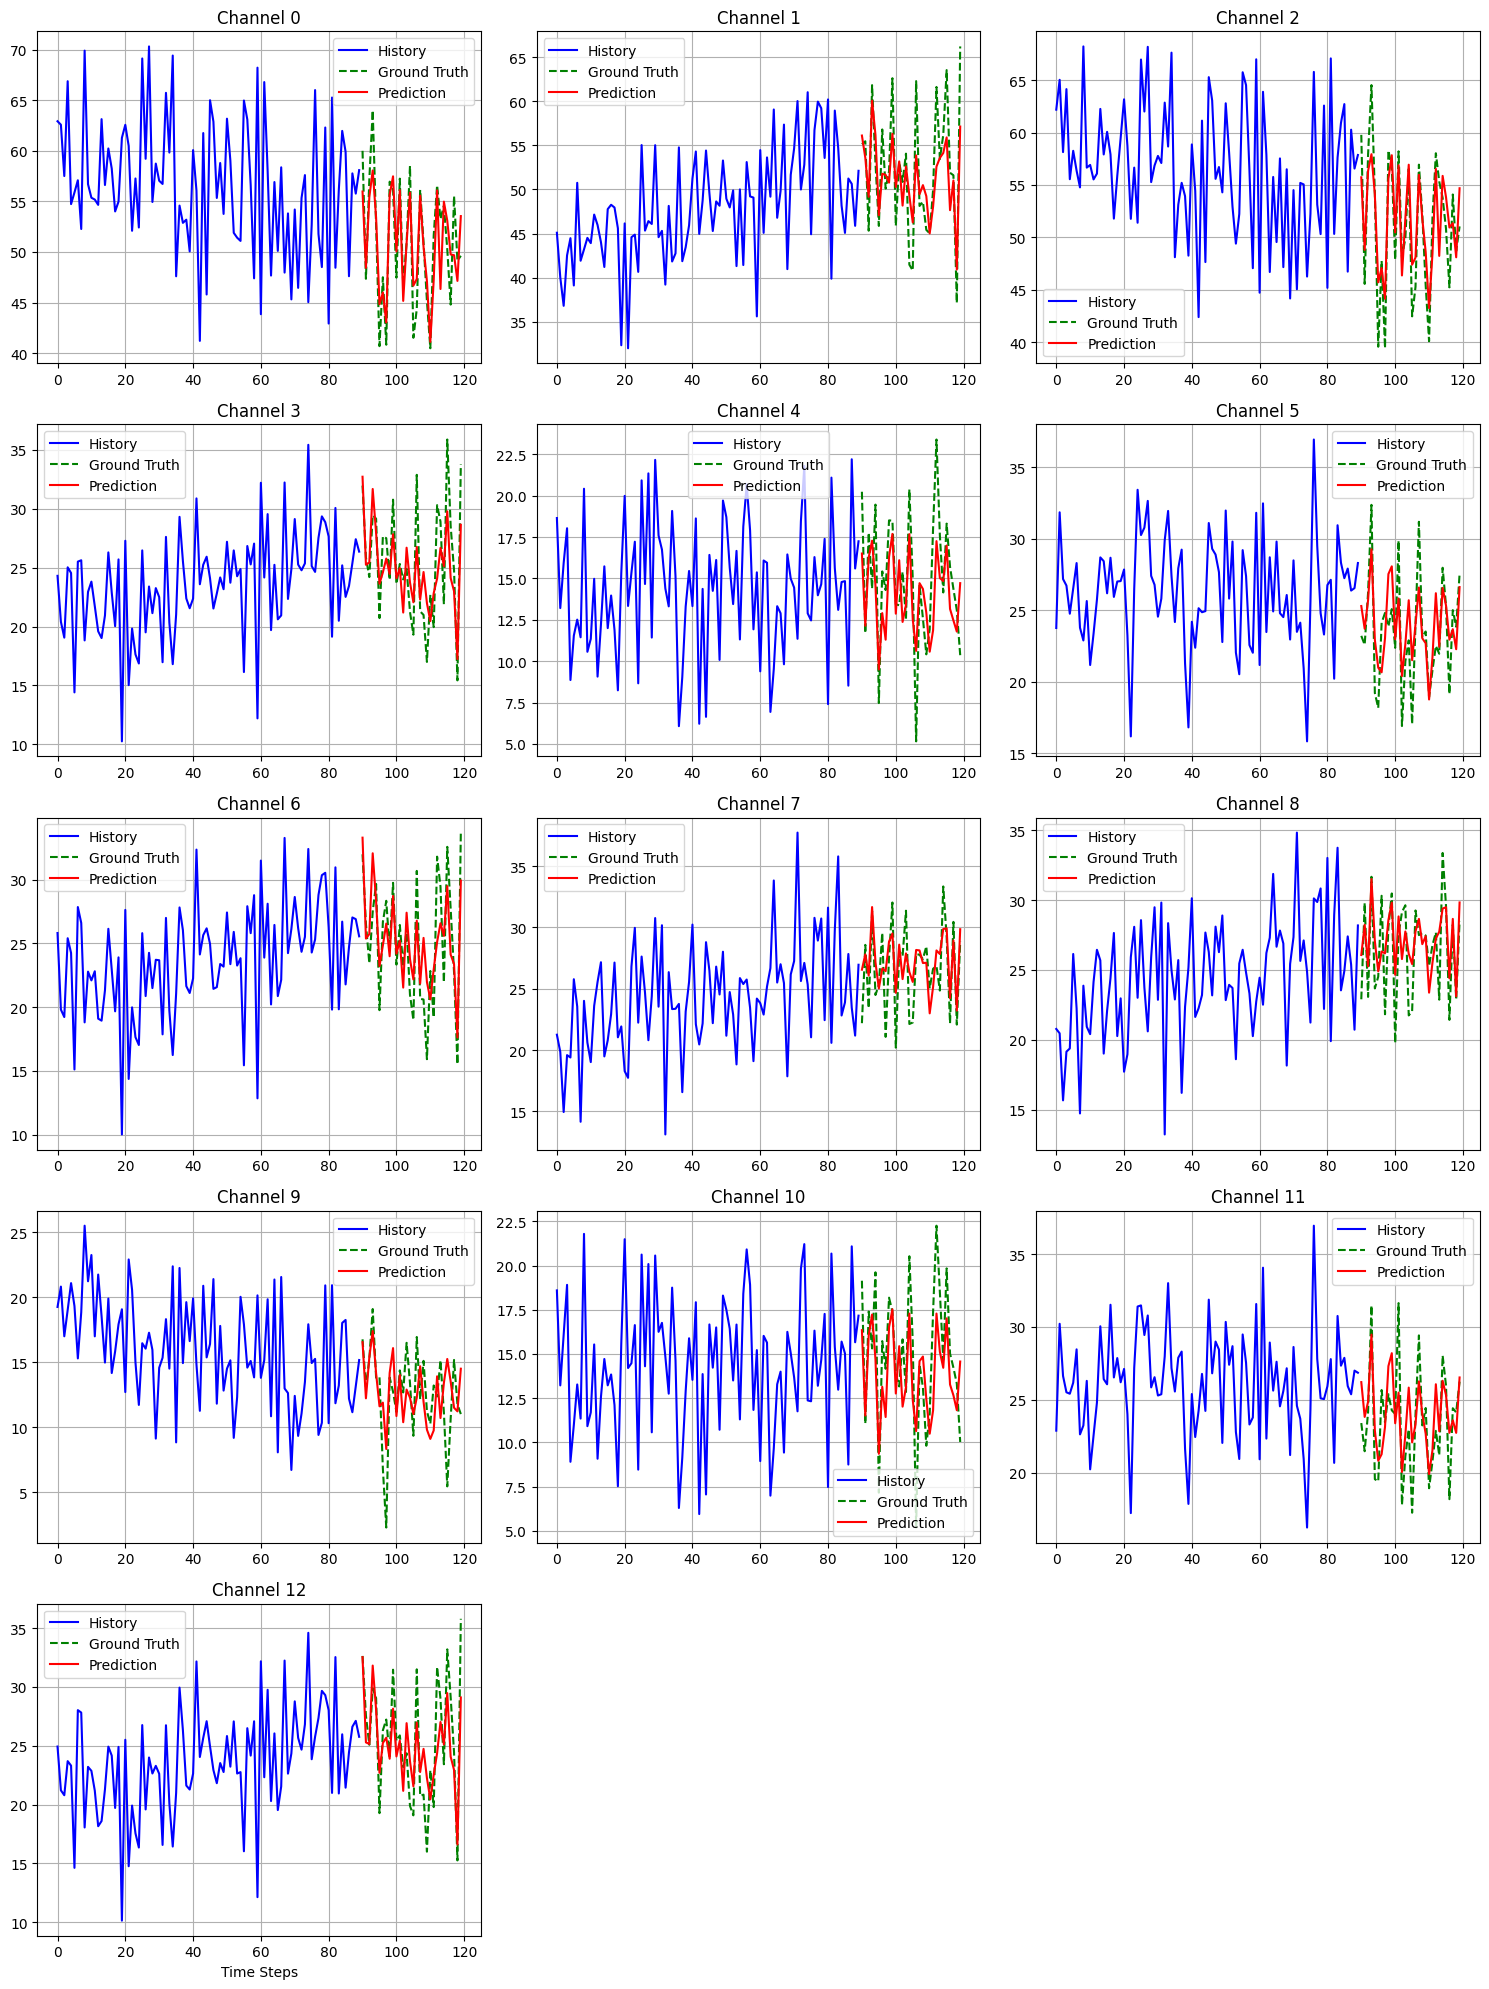

In [30]:
def plot_results(model, dataframe, seq_len, pred_len, sample_idx=0):
    """
    Plots the Input History, Ground Truth Future, and Model Prediction for a specific sample.
    """
    dataset = TimeSeriesDataset(dataframe, seq_len, pred_len)
    print(dataset[0][0].shape)
    print(dataset[0][1].shape)
    print(dataset[0][2].shape)
    # Get a single sample
    input_x, input_x_mark, true_y = dataset[sample_idx]


    # Add batch dimension for the model
    input_x_batch = input_x.unsqueeze(0)        # [1, seq_len, channels]
    input_x_mark_batch = input_x_mark.unsqueeze(0) # [1, seq_len, 4]

    print(input_x_batch.shape)
    print(input_x_mark_batch.shape)
    print(true_y.shape)


    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        input_x_batch = input_x_batch.to(device)
        input_x_mark_batch = input_x_mark_batch.to(device)
        pred_y = model(input_x_batch, input_x_mark_batch)

    # Convert to numpy for plotting
    input_x = input_x.numpy()
    true_y = true_y.numpy()
    pred_y = pred_y.cpu().numpy().squeeze(0) # Remove batch dim
    print(input_x.shape)
    print(true_y.shape)
    print(pred_y.shape)





    # Plotting
    # --- Setup for Grid Layout ---
    num_cols = 3
    num_channels = input_x.shape[1]
    # Calculate rows needed (ceiling division)
    num_rows = (num_channels + num_cols - 1) // num_cols

    # Create the subplots
    # Note: Increased width (15) to accommodate 3 columns
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows), sharex=False)

    # Flatten the axes array (makes it 1D so we can iterate over it easily)
    # If num_channels is small, axes might not be an array, so we ensure it is iterable
    if num_channels == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten()

    # Time axis for plotting
    x_history = np.arange(seq_len)
    x_future = np.arange(seq_len, seq_len + pred_len)


    for i in range(num_channels):
        ax = axes_flat[i]

        # Plot History
        ax.plot(x_history, input_x[:, i], label='History', color='blue')

        # Plot Ground Truth
        ax.plot(x_future, true_y[:, i], label='Ground Truth', color='green', linestyle='dashed')

        # Plot Prediction
        ax.plot(x_future, pred_y[:, i], label='Prediction', color='red')

        ax.set_title(f"Channel {i}")
        ax.legend()
        ax.grid(True)
    # --- Clean up empty subplots ---
    # If num_channels isn't a perfect multiple of 3, hide the empty axes at the end
    for i in range(num_channels, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    plt.xlabel("Time Steps")
    plt.tight_layout()
    #plt.show()


MODEL = PatchTST(
    num_input_channels=CHANNELS,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    n_heads=4,
    n_layers=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load('timeseries_model_noisy.pth', map_location=device)
MODEL.load_state_dict(state_dict)
MODEL.to(device)
MODEL.eval()

plot_results(MODEL, TSS, SEQ_LEN, PRED_LEN, sample_idx=40)

## MODELAMIENTO DE FLUJOS

In [103]:
NODES = np.unique(CAPACITY['A'].tolist() + CAPACITY['B'].tolist())
NODES = {x:i for i,x in enumerate(NODES)}
#NODES['INPUT'] = 0
#NODES['OUTPUT'] = 1
NODES



{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'HR_A': 6,
 'HR_B': 7,
 'INPUT': 8,
 'MR_A': 9,
 'MR_B': 10,
 'OUTPUT': 11,
 'S1_A': 12,
 'S1_C': 13,
 'S1_D': 14,
 'S1_E': 15,
 'S1_F': 16}

In [104]:
import torch
import torch.nn as nn
import torch.optim as optim


edges_data = [(NODES[x['A']],NODES[x['B']],x['Capacity']) for x in CAPACITY.to_dict('records')]
nodes = np.unique(CAPACITY['A'].tolist() + CAPACITY['B'].tolist())


NUM_NODES = len(NODES)
print(NUM_NODES)
SOURCE_NODE = 8
SINK_NODE = 11

LEARNING_RATE = 0.1
EPOCHS = 2000
LAMBDA_PHYSICS = 100.0  


17


In [105]:

# --- 2. HELPER FUNCTIONS (Matrix Setup) ---
def build_incidence_matrix(edges, num_nodes):
    indices = []
    values = []
    for i, (u, v, _) in enumerate(edges):
        # Column indices for the two directions of this edge
        idx_fwd, idx_bwd = 2 * i, 2 * i + 1
        
        # u -> v (u loses, v gains)
        indices.extend([[u, idx_fwd], [v, idx_fwd]])
        values.extend([-1.0, 1.0])
        
        # v -> u (v loses, u gains)
        indices.extend([[v, idx_bwd], [u, idx_bwd]])
        values.extend([-1.0, 1.0])

    i = torch.LongTensor(indices).t()
    v = torch.FloatTensor(values)
    return torch.sparse_coo_tensor(i, v, size=(num_nodes, 2 * len(edges)))

def vectorized_flow_loss(flows, incidence_matrix, capacities, source, sink, lambda_phys):
    # 1. Calculate Net Flow for all nodes (Matrix Mult)
    # Flatten flows to (2*E, 1) for multiplication

    flat_flows = flows.view(-1).unsqueeze(1) 
    
    net_flows = torch.sparse.mm(incidence_matrix, flat_flows).squeeze()

    # 2. Conservation Loss (Nodes must balance to 0, except Source/Sink)
    mask = torch.ones(net_flows.shape[0], dtype=torch.bool)
    mask[source] = False
    mask[sink] = False
    loss_cons = torch.sum(net_flows[mask] ** 2)

    # 3. Capacity Loss (Sum of both dirs must be <= Capacity)
    # Sum flow in both directions: shape (E, 2) -> (E,)
    total_edge_flow = torch.sum(flows, dim=1) 
    loss_cap = torch.sum(torch.relu(total_edge_flow - capacities) ** 2)

    # 4. Objective: Maximize Flow into Sink
    # We minimize negative flow
    flow_at_sink = net_flows[sink]
    loss_obj = -flow_at_sink

    return (lambda_phys * loss_cons) + (lambda_phys * loss_cap) + loss_obj, flow_at_sink


In [106]:
class FlowNetwork(nn.Module):
    def __init__(self, num_edges):
        super().__init__()
        # Parameters: Raw numbers that can be negative
        self.raw_weights = nn.Parameter(torch.randn(num_edges, 2))
    
    def forward(self):
        # Apply ReLU so the solver physically cannot output negative flow
        return torch.relu(self.raw_weights)


In [107]:
incidence_matrix = build_incidence_matrix(edges_data, NUM_NODES)
capacities = torch.tensor([e[2] for e in edges_data], dtype=torch.float32)

model = FlowNetwork(len(edges_data))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [108]:
print(f"{'Epoch':<10} | {'Loss':<10} | {'Sink Flow':<10} | {'Status'}")
print("-" * 50)

for epoch in range(EPOCHS):
    optimizer.zero_grad()  # Reset gradients
    
    # Forward Pass
    current_flows = model()
    
    # Calculate Loss
    loss, sink_flow = vectorized_flow_loss(
        current_flows, 
        incidence_matrix, 
        capacities, 
        SOURCE_NODE, 
        SINK_NODE, 
        LAMBDA_PHYSICS
    )
    
    # Backward Pass (Compute Gradients)
    loss.backward()
    
    # Update Weights
    optimizer.step()
    
    # Monitoring
    if epoch % 500 == 0 or epoch == EPOCHS - 1:
        print(f"{epoch:<10} | {loss.item():.4f}     | {sink_flow.item():.4f}     | Training...")


Epoch      | Loss       | Sink Flow  | Status
--------------------------------------------------
0          | 6376.7456     | -2.3582     | Training...
500        | 0.0008     | 0.0000     | Training...
1000       | 0.0000     | 0.0000     | Training...
1500       | 0.0000     | 0.0000     | Training...
1999       | 0.0000     | 0.0000     | Training...


In [109]:

print("\n--- FINAL RESULTS ---")
final_flows = model().detach() # Detach from gradient graph for printing
total_sink_flow = 0

for i, (u, v, cap) in enumerate(edges_data):
    f_uv = final_flows[i, 0].item()
    f_vu = final_flows[i, 1].item()
    
    # Only print significant flows
    if f_uv > 0.01 or f_vu > 0.01:
        print(f"Edge {u}-{v} (Max {cap}): \t{f_uv:.2f} -> \t{f_vu:.2f} <-")

print(f"\nFinal Calculated Max Flow: {vectorized_flow_loss(final_flows, incidence_matrix, capacities, SOURCE_NODE, SINK_NODE, 0)[1].item():.2f}")


--- FINAL RESULTS ---
Edge 9-6 (Max 1000): 	1.74 -> 	1.74 <-
Edge 10-7 (Max 1000): 	1.61 -> 	0.00 <-
Edge 3-5 (Max 1000): 	0.00 -> 	1.37 <-
Edge 7-10 (Max 1000): 	1.61 -> 	0.00 <-
Edge 1-2 (Max 1000): 	0.38 -> 	0.00 <-
Edge 4-3 (Max 1000): 	1.30 -> 	1.30 <-
Edge 5-3 (Max 1000): 	0.00 -> 	1.37 <-
Edge 2-1 (Max 1000): 	0.38 -> 	0.00 <-
Edge 8-6 (Max 1000): 	0.99 -> 	0.99 <-

Final Calculated Max Flow: 0.00
